# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV168"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv168')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv168/lv168-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV168,gene_band
0,PSMC4,6.839818,19q13.2
1,EXOSC5,6.073043,19q13.2
2,PEBP1,5.072184,12q24.23
3,PRDX5,4.556722,11q13.1
4,NHP2,4.109085,5q35.3
5,TCERG1,3.276480,5q32
6,CDC45,2.685517,22q11.21
7,RPL37A,2.569045,2q35
8,CCT7,2.535890,2p13.2
9,NAA38,2.429107,17p13.1


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 15:37:03,626 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 15:37:03,627 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP033135, SRP042161, SRP063840, SRP055569, SRP012461, SRP057196, SRP042218, SRP059775, SRP060416, SRP058351, SRP026315, SRP066834, SRP064464, SRP051606, SRP059379, SRP009266, SRP034953, SRP006575, SRP036821, SRP009276, SRP007359, SRP011546, SRP009247, SRP055153, SRP025989, SRP066729, SRP050499, SRP012557, SRP005279, SRP007947, SRP018838, SRP014428, SRP029334, SRP023262, SRP007596, SRP058773, SRP031507, SRP014542, SRP011054, SRP045869, SRP009862, SRP006475, SRP033119, SRP017777, SRP050992, SRP036053, SRP022920, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (43 != 47)
  warnings.warn(


In [12]:
lv_data.shape

(6236, 72)

In [13]:
lv_data.head()

cell type  \
project   run                                                  
SRP033135 SRR1032910  Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1032911  Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1032912  Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1032913  Human Skeletal Muscle Myoblasts (HSMM)   
          SRR1032914  Human Skeletal Muscle Myoblasts (HSMM)   

                     hour post serum-switch debris control well cells in well  \
project   run                                                                   
SRP033135 SRR1032910                      0  FALSE        FALSE             1   
          SRR1032911                      0  FALSE        FALSE             1   
          SRR1032912                      0  FALSE        FALSE             1   
          SRR1032913                      0  FALSE        FALSE             2   
          SRR1032914                      0  FALSE        FALSE             1   

                     library protocol cell line patient id subtype  \
project   run                                                        
SRP033135 SRR1032910      Single-cell       NaN        NaN     NaN   
          SRR1032911      Single-cell       NaN        NaN     NaN   
          SRR1032912      Single-cell       NaN        NaN     NaN   
          SRR1032913      Single-cell       NaN        NaN     NaN   
          SRR1032914      Single-cell       NaN        NaN     NaN   

                     cell source  ... passages modified nucleotide  \
project   run                     ...                                
SRP033135 SRR1032910         NaN  ...      NaN                 NaN   
          SRR1032911         NaN  ...      NaN                 NaN   
          SRR1032912         NaN  ...      NaN                 NaN   
          SRR1032913         NaN  ...      NaN                 NaN   
          SRR1032914         NaN  ...      NaN                 NaN   

                     crosslinking sirna transfection protein expressed  \
project   run                                                            
SRP033135 SRR1032910          NaN                NaN               NaN   
          SRR1032911          NaN                NaN               NaN   
          SRR1032912          NaN                NaN               NaN   
          SRR1032913          NaN                NaN               NaN   
          SRR1032914          NaN                NaN               NaN   

                     molecule subtype origin antibodies cell cycle phase  \
project   run                                                              
SRP033135 SRR1032910              NaN    NaN        NaN              NaN   
          SRR1032911              NaN    NaN        NaN              NaN   
          SRR1032912              NaN    NaN        NaN              NaN   
          SRR1032913              NaN    NaN        NaN              NaN   
          SRR1032914              NaN    NaN        NaN              NaN   

                         LV168  
project   run                   
SRP033135 SRR1032910 -0.008233  
          SRR1032911  0.017024  
          SRR1032912 -0.005545  
          SRR1032913 -0.014283  
          SRR1032914  0.021252  

[5 rows x 72 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

debris                    0.253081
library protocol          0.253081
cells in well             0.253081
control well              0.253081
hour post serum-switch    0.253081
cell line                 0.047054
cell type                 0.032641
overexpression            0.018593
cell source               0.006858
patient id                0.005070
antibody                  0.004163
time                      0.003547
tissue compartment        0.003356
iPSc                      0.003029
reprogramming vector      0.003029
antibody lot #            0.002459
antibody cat. #           0.002459
antibody vendor           0.002459
bar code                  0.002444
antibody for pull-down    0.002444
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell line         0.047054
cell type         0.032641
tissue            0.001493
tissue subtype    0.000927
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "cell line",
    "cell type",
    "tissue",
    "tissue subtype",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

cell line                               cell type tissue  \
project   run                                                                   
SRP033135 SRR1033199       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
          SRR1033243       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
          SRR1032931       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
          SRR1032925       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
          SRR1032949       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
          SRR1033220       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
SRP042161 SRR1295257      CSC6                  Gliomasphere Cell Line    NaN   
SRP033135 SRR1032955       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
          SRR1033221       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
          SRR1033276       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
          SRR1033003       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
          SRR1032991       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
          SRR1032937       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
SRP042161 SRR1295186      CSC6                  Gliomasphere Cell Line    NaN   
          SRR1295247      CSC6                  Gliomasphere Cell Line    NaN   
          SRR1295204      CSC6                  Gliomasphere Cell Line    NaN   
SRP033135 SRR1033265       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
          SRR1032943       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
          SRR1032979       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
SRP042161 SRR1295205      CSC6                  Gliomasphere Cell Line    NaN   
SRP033135 SRR1033244       NaN  Human Skeletal Muscle Myoblasts (HSMM)    NaN   
SRP042161 SRR1295170      CSC6                  Gliomasphere Cell Line    NaN   
          SRR1295290      CSC8                  Gliomasphere Cell Line    NaN   
          SRR1295260      CSC8                  Gliomasphere Cell Line    NaN   
          SRR1295183      CSC6                  Gliomasphere Cell Line    NaN   

                     tissue subtype     LV168  
project   run                                  
SRP033135 SRR1033199            NaN  4.682801  
          SRR1033243            NaN  3.652443  
          SRR1032931            NaN  2.996226  
          SRR1032925            NaN  2.863417  
          SRR1032949            NaN  2.588056  
          SRR1033220            NaN  2.552604  
SRP042161 SRR1295257            NaN  2.529610  
SRP033135 SRR1032955            NaN  2.357542  
          SRR1033221            NaN  2.327291  
          SRR1033276            NaN  2.040838  
          SRR1033003            NaN  1.954428  
          SRR1032991            NaN  1.884192  
          SRR1032937            NaN  1.703590  
SRP042161 SRR1295186            NaN  1.648311  
          SRR1295247            NaN  1.629403  
          SRR1295204            NaN  1.606567  
SRP033135 SRR1033265            NaN  1.598295  
          SRR1032943            NaN  1.552523  
          SRR1032979            NaN  1.533761  
SRP042161 SRR1295205            NaN  1.470962  
SRP033135 SRR1033244            NaN  1.288265  
SRP042161 SRR1295170            NaN  1.274836  
          SRR1295290            NaN  1.198768  
          SRR1295260            NaN  1.181017  
          SRR1295183            NaN  1.010397

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [21]:
_tmp_seq[1]

cell line                        cell type tissue  \
project   run                                                            
SRP042161 SRR1295164      CSC6           Gliomasphere Cell Line    NaN   
          SRR1295241      CSC6           Gliomasphere Cell Line    NaN   
          SRR1295278      CSC8           Gliomasphere Cell Line    NaN   
          SRR1295261      CSC8           Gliomasphere Cell Line    NaN   
          SRR1295201      CSC6           Gliomasphere Cell Line    NaN   
          SRR1295238      CSC6           Gliomasphere Cell Line    NaN   
          SRR1295172      CSC6           Gliomasphere Cell Line    NaN   
          SRR1295317      CSC8           Gliomasphere Cell Line    NaN   
SRP063840 SRR2431411       NaN     primary renal cell carcinoma    NaN   
SRP042161 SRR1294809       NaN                     Glioblastoma    NaN   
          SRR1295255      CSC6           Gliomasphere Cell Line    NaN   
          SRR1295179      CSC6           Gliomasphere Cell Line    NaN   
SRP055569 SRR2019024       NaN           U87 human glioma cells    NaN   
SRP042161 SRR1295307      CSC8           Gliomasphere Cell Line    NaN   
SRP063840 SRR2431431       NaN  metastatic renal cell carcinoma    NaN   
SRP042161 SRR1294821       NaN                     Glioblastoma    NaN   
SRP055569 SRR2019051       NaN           U87 human glioma cells    NaN   
SRP042161 SRR1295224      CSC6           Gliomasphere Cell Line    NaN   
SRP055569 SRR2018993       NaN           U87 human glioma cells    NaN   
SRP042161 SRR1295036       NaN                     Glioblastoma    NaN   
          SRR1295282      CSC8           Gliomasphere Cell Line    NaN   
SRP012461 SRR490308        NaN           Mesenchymal Stem Cells    NaN   
SRP042161 SRR1295166      CSC6           Gliomasphere Cell Line    NaN   
          SRR1295195      CSC6           Gliomasphere Cell Line    NaN   
SRP055569 SRR2019007       NaN           U87 human glioma cells    NaN   

                     tissue subtype     LV168  
project   run                                  
SRP042161 SRR1295164            NaN  1.008975  
          SRR1295241            NaN  0.965973  
          SRR1295278            NaN  0.948977  
          SRR1295261            NaN  0.868555  
          SRR1295201            NaN  0.861459  
          SRR1295238            NaN  0.841213  
          SRR1295172            NaN  0.776214  
          SRR1295317            NaN  0.776019  
SRP063840 SRR2431411            NaN  0.676688  
SRP042161 SRR1294809            NaN  0.632026  
          SRR1295255            NaN  0.622932  
          SRR1295179            NaN  0.621211  
SRP055569 SRR2019024            NaN  0.591266  
SRP042161 SRR1295307            NaN  0.563379  
SRP063840 SRR2431431            NaN  0.563314  
SRP042161 SRR1294821            NaN  0.551690  
SRP055569 SRR2019051            NaN  0.519892  
SRP042161 SRR1295224            NaN  0.519292  
SRP055569 SRR2018993            NaN  0.517686  
SRP042161 SRR1295036            NaN  0.516423  
          SRR1295282            NaN  0.487979  
SRP012461 SRR490308             NaN  0.487757  
SRP042161 SRR1295166            NaN  0.473242  
          SRR1295195            NaN  0.464933  
SRP055569 SRR2019007            NaN  0.451539

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [22]:
# list the top 10 samples from this project
lv_data.loc[["SRP039591"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP039591'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [23]:
SELECTED_ATTRIBUTES = [
    "cell line",
    "cell type",
    "tissue",
    "tissue subtype",
]

## Get a single attribute with "cell type/tissue" information

In [24]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [25]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [26]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [27]:
plot_data.head(20)

cell line     LV168
project   run                                                         
SRP033135 SRR1033199  Human Skeletal Muscle Myoblasts (HSMM)  4.682801
          SRR1033243  Human Skeletal Muscle Myoblasts (HSMM)  3.652443
          SRR1032931  Human Skeletal Muscle Myoblasts (HSMM)  2.996226
          SRR1032925  Human Skeletal Muscle Myoblasts (HSMM)  2.863417
          SRR1032949  Human Skeletal Muscle Myoblasts (HSMM)  2.588056
          SRR1033220  Human Skeletal Muscle Myoblasts (HSMM)  2.552604
SRP042161 SRR1295257                                    CSC6  2.529610
SRP033135 SRR1032955  Human Skeletal Muscle Myoblasts (HSMM)  2.357542
          SRR1033221  Human Skeletal Muscle Myoblasts (HSMM)  2.327291
          SRR1033276  Human Skeletal Muscle Myoblasts (HSMM)  2.040838
          SRR1033003  Human Skeletal Muscle Myoblasts (HSMM)  1.954428
          SRR1032991  Human Skeletal Muscle Myoblasts (HSMM)  1.884192
          SRR1032937  Human Skeletal Muscle Myoblasts (HSMM)  1.703590
SRP042161 SRR1295186                                    CSC6  1.648311
          SRR1295247                                    CSC6  1.629403
          SRR1295204                                    CSC6  1.606567
SRP033135 SRR1033265  Human Skeletal Muscle Myoblasts (HSMM)  1.598295
          SRR1032943  Human Skeletal Muscle Myoblasts (HSMM)  1.552523
          SRR1032979  Human Skeletal Muscle Myoblasts (HSMM)  1.533761
SRP042161 SRR1295205                                    CSC6  1.470962

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [28]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [29]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [30]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [31]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [32]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [33]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [34]:
N_TOP_ATTRS = 10

In [35]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [36]:
len(attr_order)

10

In [37]:
attr_order[:5]

['Human Skeletal Muscle Myoblasts (HSMM)',
 'CSC6',
 'CSC8',
 'primary renal cell carcinoma',
 'Glioblastoma']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

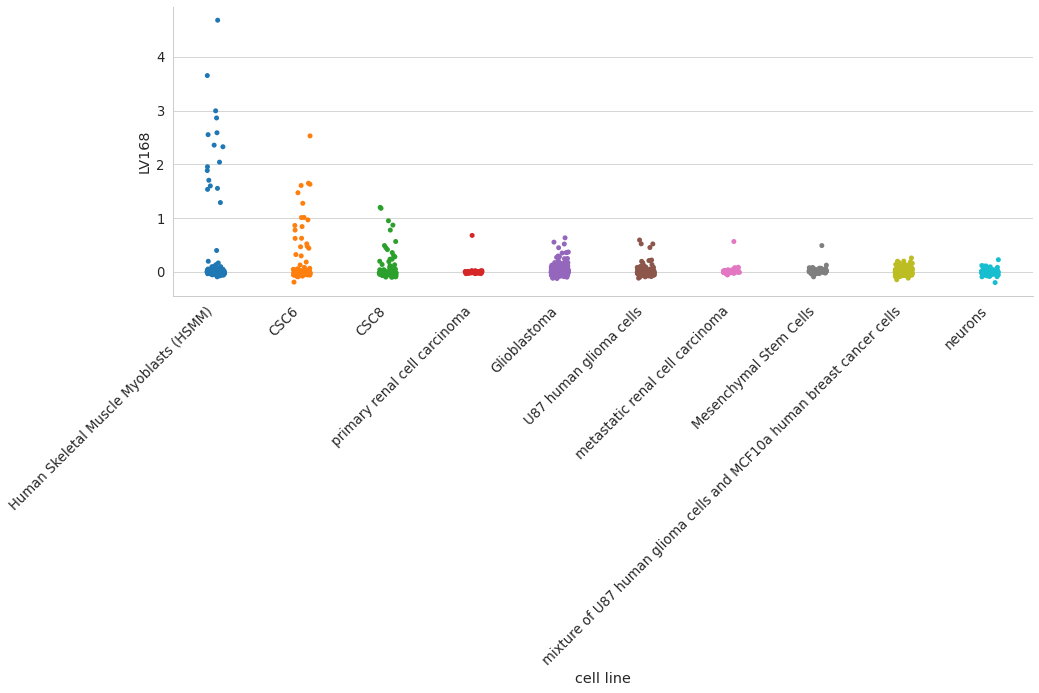

In [38]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [39]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("CSC6")
    ]
    display(_tmp.head(20))

cell line     LV168
project   run                           
SRP042161 SRR1295257      CSC6  2.529610
          SRR1295186      CSC6  1.648311
          SRR1295247      CSC6  1.629403
          SRR1295204      CSC6  1.606567
          SRR1295205      CSC6  1.470962
          SRR1295170      CSC6  1.274836
          SRR1295183      CSC6  1.010397
          SRR1295164      CSC6  1.008975
          SRR1295241      CSC6  0.965973
          SRR1295201      CSC6  0.861459
          SRR1295238      CSC6  0.841213
          SRR1295172      CSC6  0.776214
          SRR1295255      CSC6  0.622932
          SRR1295179      CSC6  0.621211
          SRR1295224      CSC6  0.519292
          SRR1295166      CSC6  0.473242
          SRR1295195      CSC6  0.464933
          SRR1295178      CSC6  0.437974
          SRR1295169      CSC6  0.320050
          SRR1295165      CSC6  0.295685

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP042161, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP057205"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell line gfp cd13 ssea4 tra160     LV141
project   run                                                    
SRP057205 SRR1975499  Detroit 551   -   NA     +      -  9.577487
          SRR1975500  Detroit 551   -   NA     +      -  9.572314
          SRR1975492  Detroit 551   -   NA     +      +  0.289487
          SRR1975491  Detroit 551   -   NA     +      +  0.287985
          SRR1975465           H9  NA   NA    NA     NA  0.188417
          SRR1975466           H9  NA   NA    NA     NA  0.187708
          SRR1975486  Detroit 551   +   NA     -      -  0.175337
          SRR1975485  Detroit 551   +   NA     -      -  0.169627
          SRR1975477  Detroit 551   +    +     -     NA  0.154895
          SRR1975478  Detroit 551   +    +     -     NA  0.154230
          SRR1975503  Detroit 551   -   NA     +      +  0.150780
          SRR1975504  Detroit 551   -   NA     +      +  0.150079
          SRR1975493  Detroit 551   -   NA     +      +  0.148080
          SRR1975494  Detroit 551   -   NA     +      +  0.147454
          SRR1975487  Detroit 551   -   NA     +      -  0.146173
          SRR1975463           H1  NA   NA    NA     NA  0.141653
          SRR1975464           H1  NA   NA    NA     NA  0.141360
          SRR1975467         PGP1  NA   NA    NA     NA  0.137427
          SRR1975468         PGP1  NA   NA    NA     NA  0.137162
          SRR1975473  Detroit 551   +    +    NA     NA  0.109797
          SRR1975474  Detroit 551   +    +    NA     NA  0.109508
          SRR1975459  Detroit 551  NA   NA    NA     NA  0.109031
          SRR1975460  Detroit 551  NA   NA    NA     NA  0.108740
          SRR1975497  Detroit 551   +   NA     +      -  0.107607
          SRR1975455  Detroit 551  NA   NA    NA     NA  0.107491
          SRR1975482  Detroit 551   +    -     +     NA  0.107362
          SRR1975498  Detroit 551   +   NA     +      -  0.107218
          SRR1975456  Detroit 551  NA   NA    NA     NA  0.107138
          SRR1975481  Detroit 551   +    -     +     NA  0.106675
          SRR1975457  Detroit 551  NA   NA    NA     NA  0.096320
          SRR1975458  Detroit 551  NA   NA    NA     NA  0.096054
          SRR1975488  Detroit 551   -   NA     +      -  0.077017
          SRR1975469  Detroit 551   +    -    NA     NA  0.063911
          SRR1975470  Detroit 551   +    -    NA     NA  0.063908
          SRR1975475  Detroit 551   +    -     -     NA  0.053077
          SRR1975479  Detroit 551   +    +     +     NA  0.053047
          SRR1975480  Detroit 551   +    +     +     NA  0.052734
          SRR1975476  Detroit 551   +    -     -     NA  0.052328
          SRR1975462  Detroit 551  NA   NA    NA     NA  0.027939
          SRR1975501  Detroit 551   -   NA     +      +  0.027924
          SRR1975461  Detroit 551  NA   NA    NA     NA  0.027917
          SRR1975502  Detroit 551   -   NA     +      +  0.027490
          SRR1975489  Detroit 551   +   NA     +      -  0.013985
          SRR1975490  Detroit 551   +   NA     +      -  0.013498
          SRR1975484  Detroit 551   -    -     +     NA  0.013459
          SRR1975483  Detroit 551   -    -     +     NA  0.013109
          SRR1975453  Detroit 551  NA   NA    NA     NA  0.011542
          SRR1975454  Detroit 551  NA   NA    NA     NA  0.011450
          SRR1975472  Detroit 551   +    +    NA     NA  0.001346
          SRR1975471  Detroit 551   +    +    NA     NA  0.001268
          SRR1975495  Detroit 551   +   NA     -      - -0.000362
          SRR1975496  Detroit 551   +   NA     -      - -0.000371
          SRR1975505  Detroit 551  NA   NA    NA     NA -0.008555
          SRR1975506  Detroit 551  NA   NA    NA     NA -0.010003
          SRR1975508  Detroit 551  NA   NA    NA     NA -0.010864
          SRR1975507  Detroit 551  NA   NA    NA     NA -0.015505

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.